Loaded fold 0 cohort file: (15700, 81)
  Excluded 3,163 outer-holdout rows (reserved for NB07).
  Retained 12,537 outer-training rows for this EDA run.

Fold 0 (train partition): (12537, 81)
  risky_upgrade (comparison) : 1,094  (8.7%)
  safe_upgrade  (control)    : 11,443  (91.3%)
  Post-upgrade default rate  : 8.73%

Financial features available for analysis: 64

[Section 1] Cohort overview (fold 0, train partition)


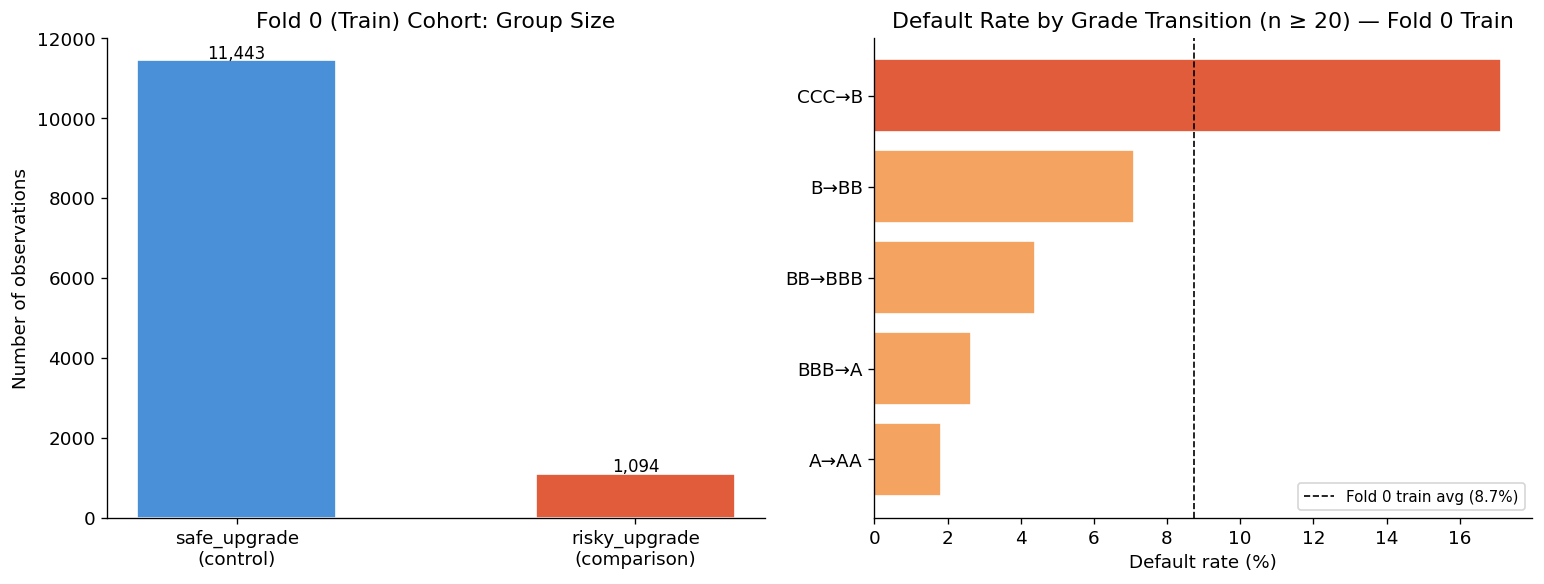

Figure saved: NB02_01_cohort_overview_fold0.png

[Section 2] Descriptive statistics (fold 0, train partition)
Saved: ../results/tables/NB02_01_descriptive_stats_fold0.csv

Top 10 features by absolute mean difference (risky - safe):
                             risky_mean  safe_mean  mean_diff
feature                                                      
Attr55                        -929.7542  1632.5265 -2562.2807
Attr15                        1670.0183  2155.7712  -485.7529
cash_to_current_liabilities   -103.2027   -33.2761   -69.9266
Attr32                         195.3232   134.8470    60.4763
Attr62                         189.6515   131.6673    57.9842
Attr27                          20.9511    34.6740   -13.7229
Attr43                         128.2240   118.4931     9.7309
Attr44                          69.8044    63.9351     5.8693
Attr60                          35.0849    30.8889     4.1960
Attr20                          54.5738    52.0245     2.5493

[Section 3] Mann-Whitne

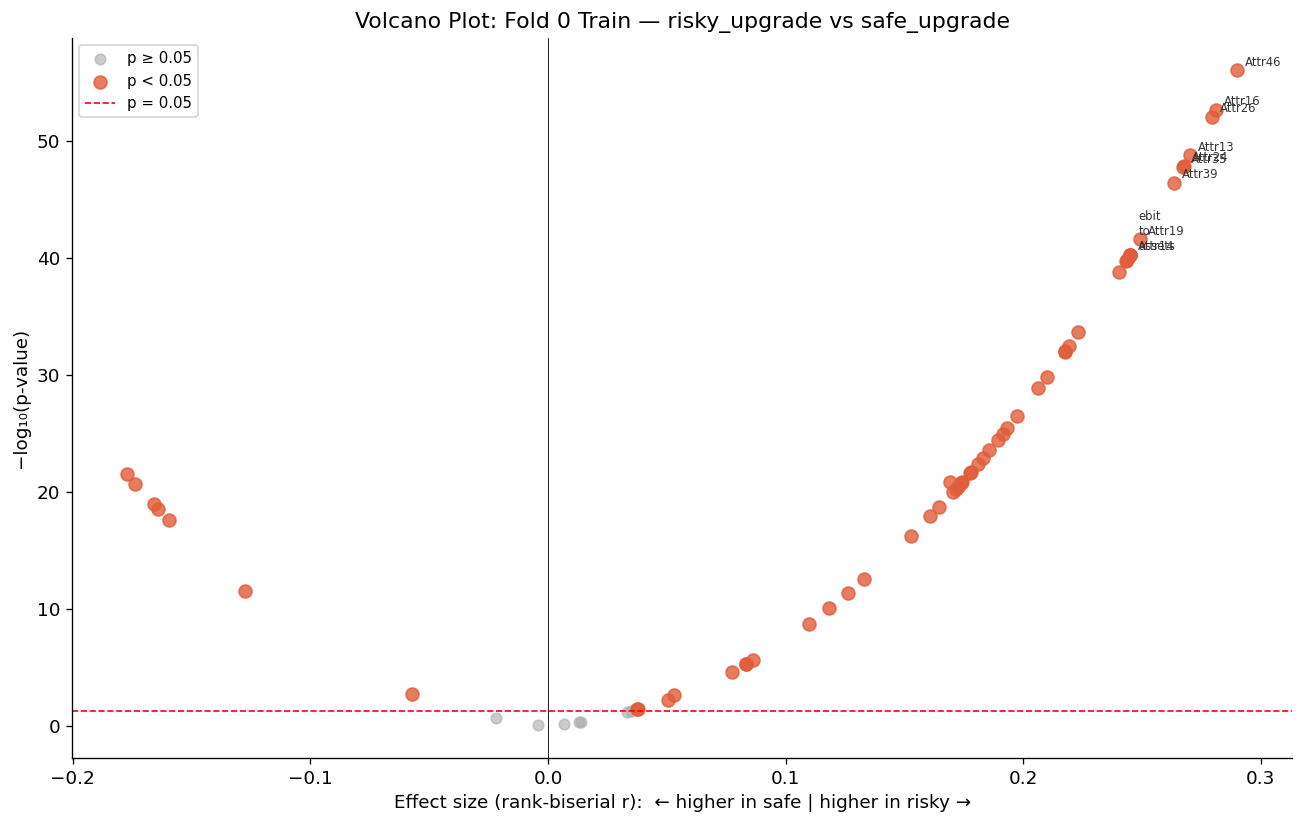

Figure saved: NB02_02_volcano_plot_fold0.png

[Section 5] Box plots — top 20 significant variables (fold 0)


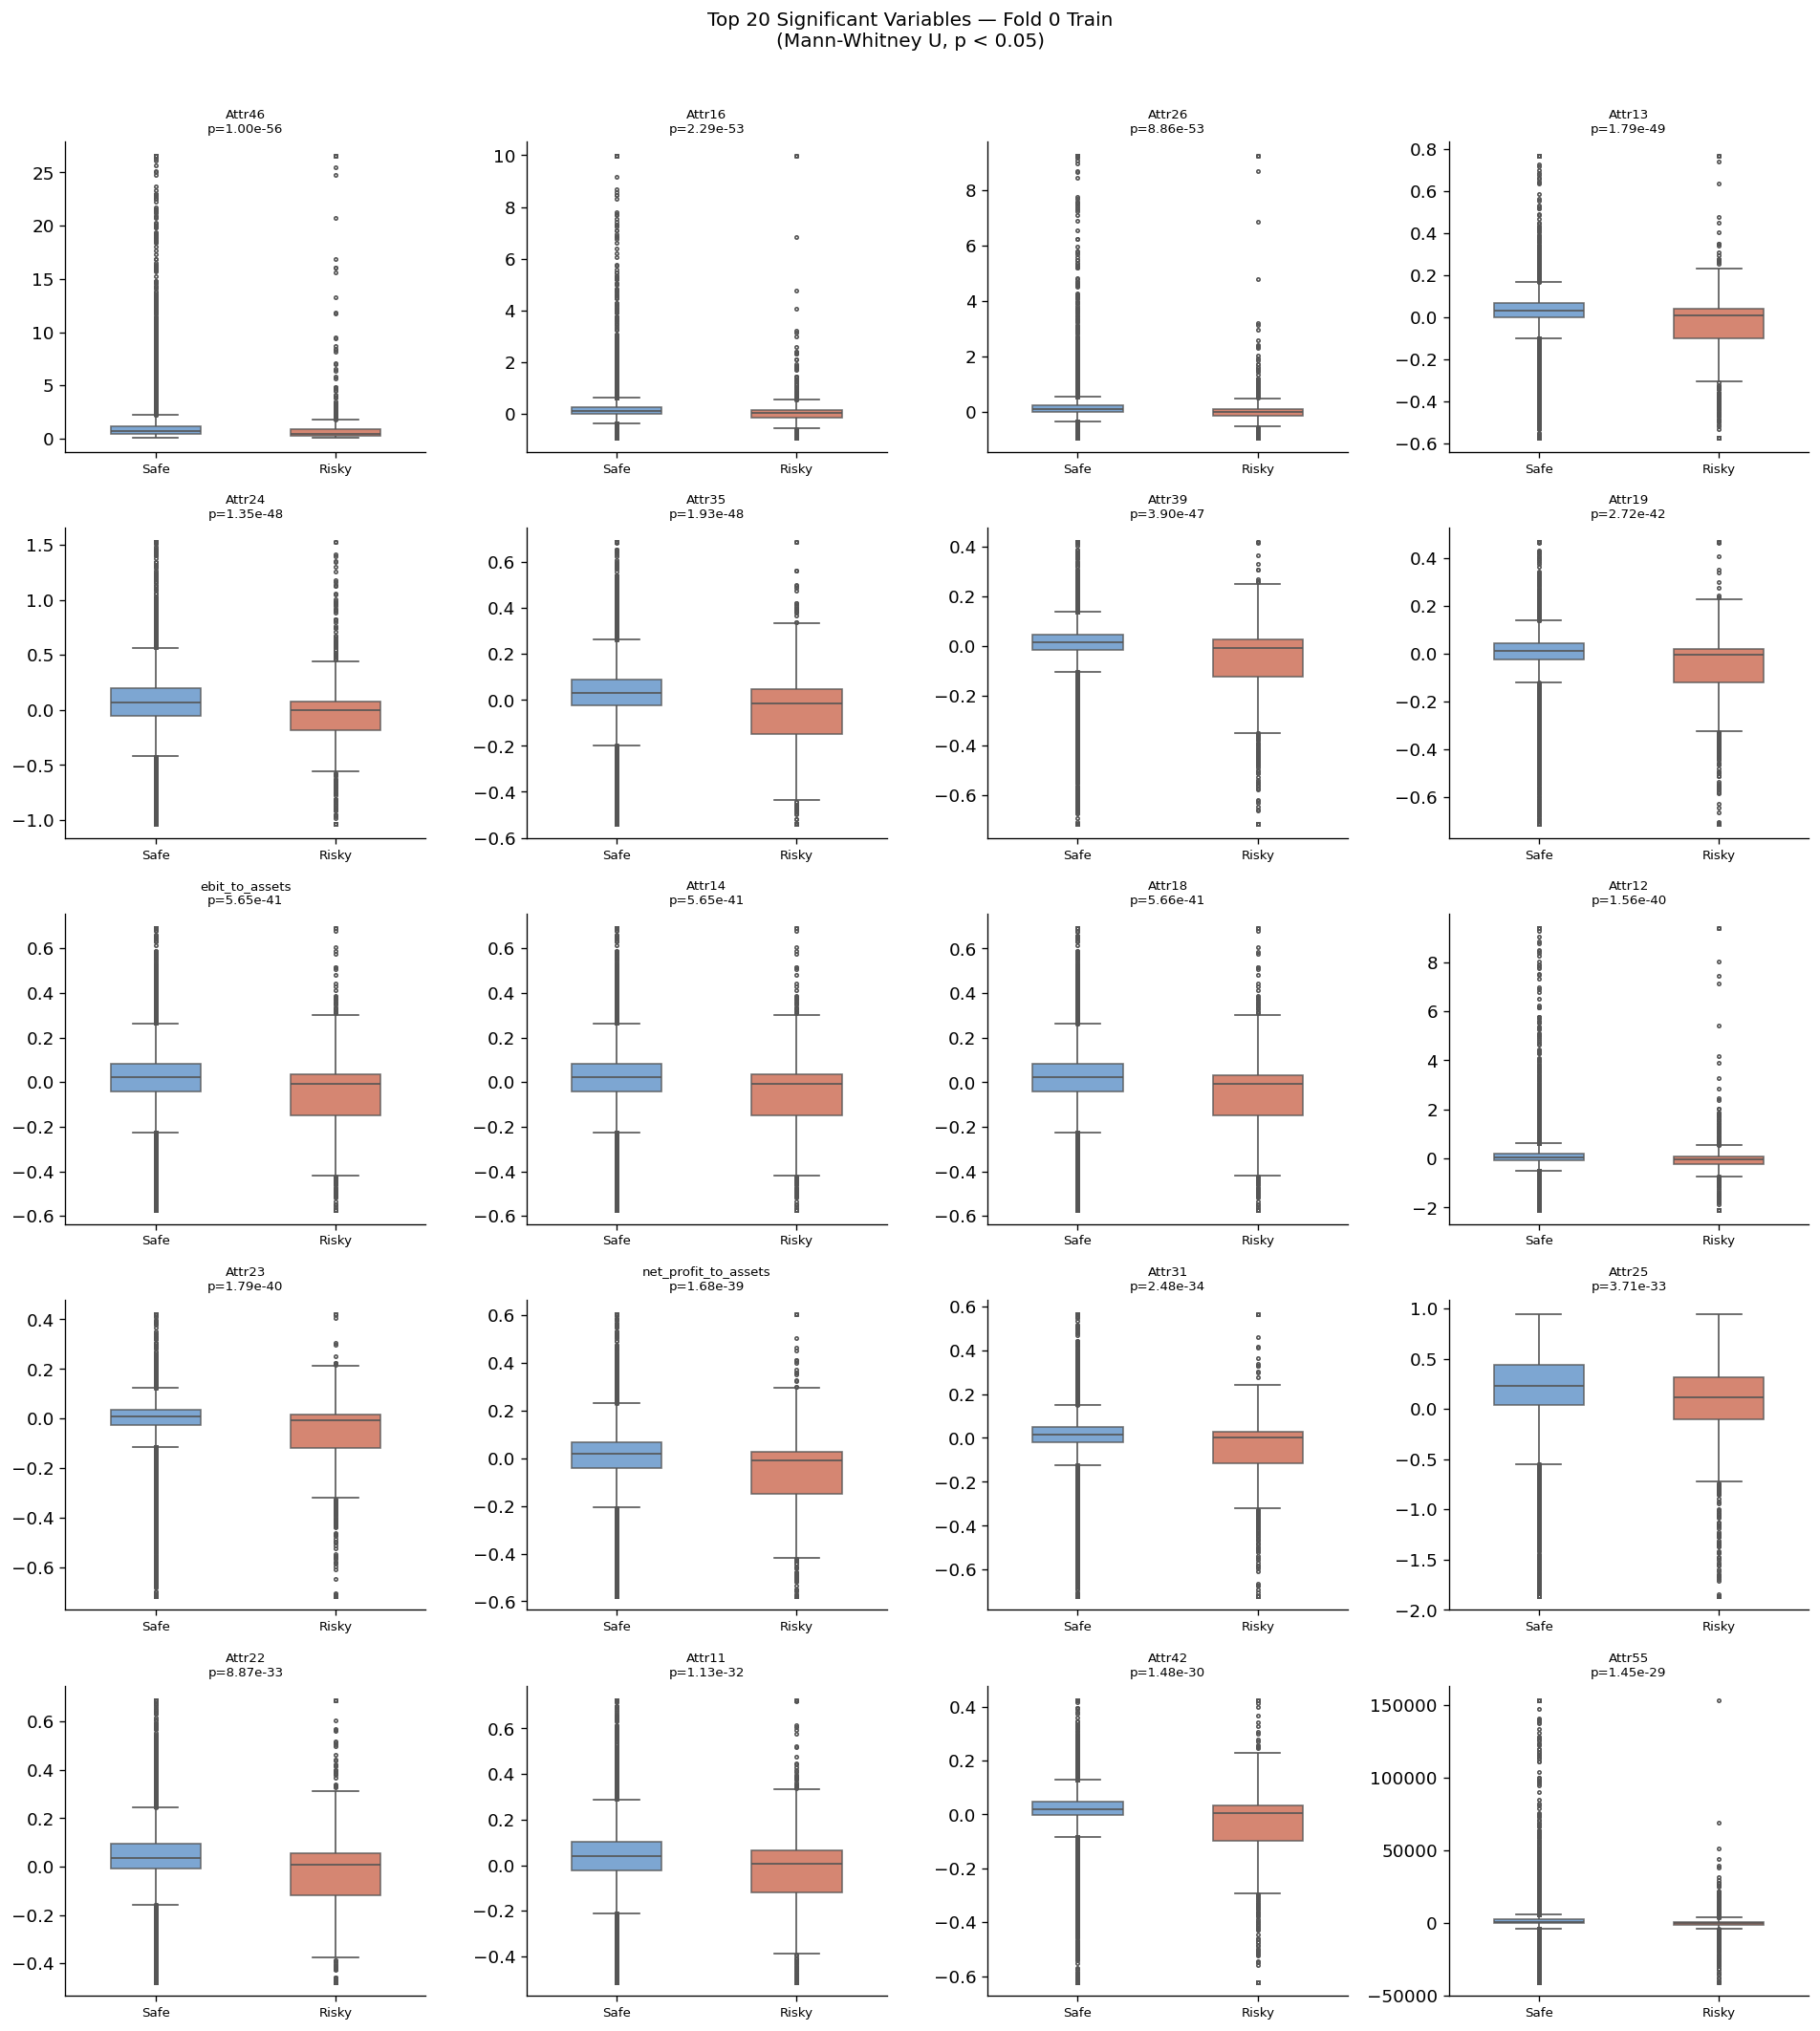

Figure saved: NB02_03_boxplots_top20_fold0.png

[Section 6] Distribution histograms — top 6 variables (fold 0)


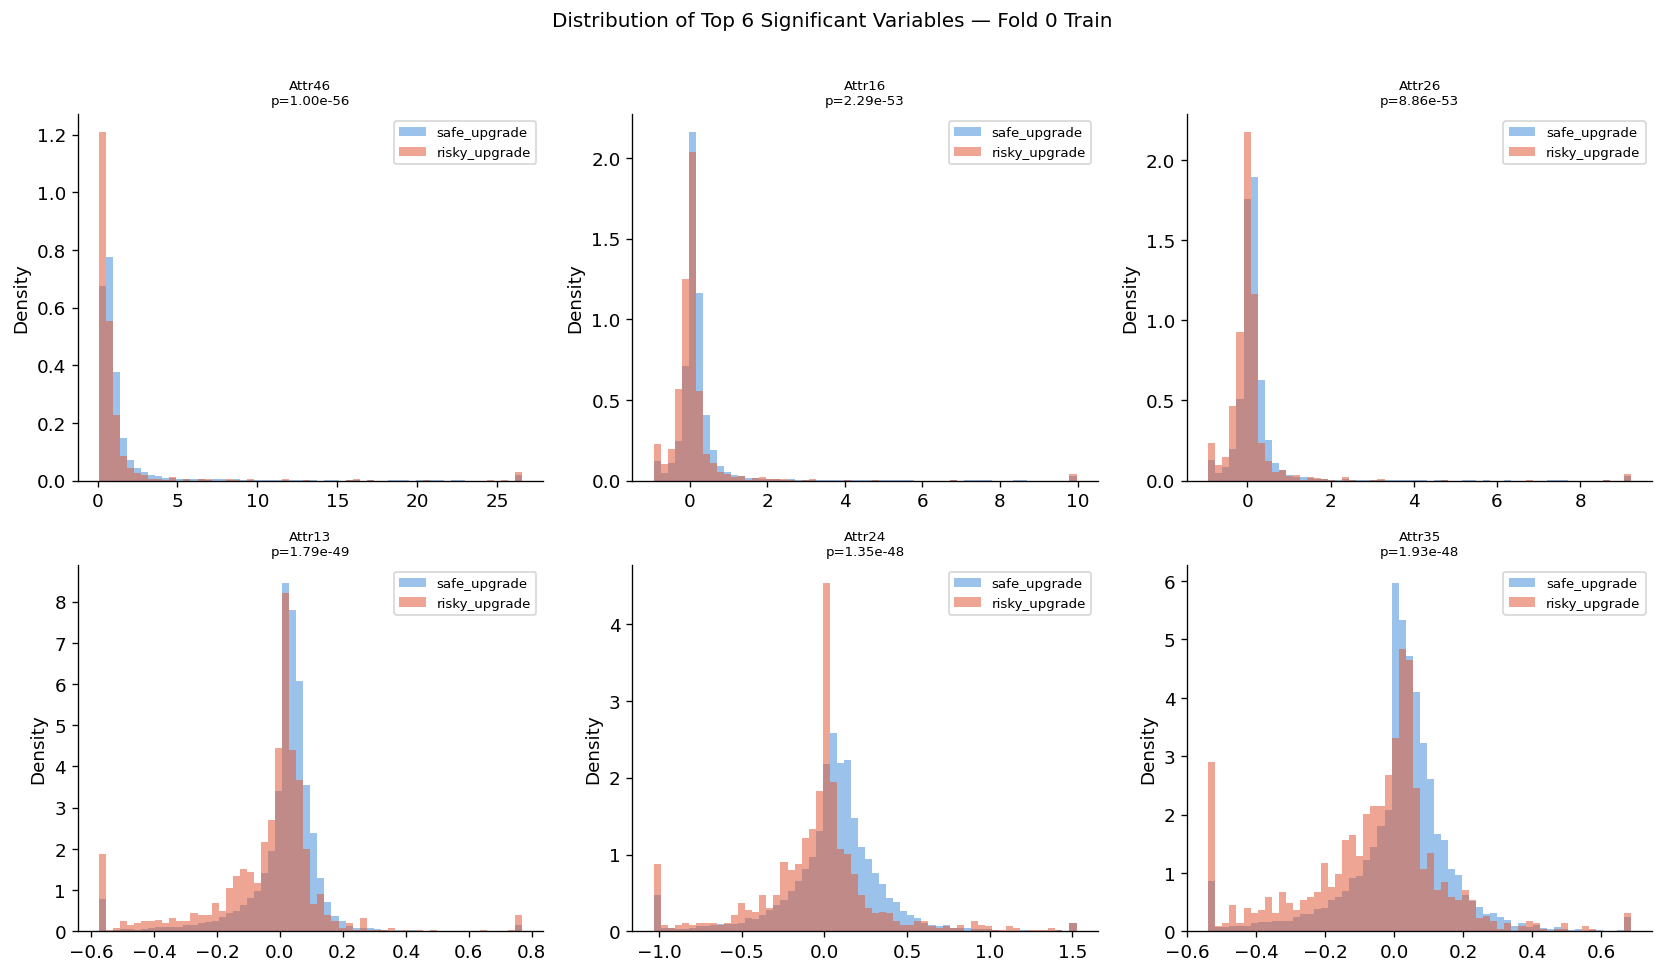

Figure saved: NB02_04_histograms_top6_fold0.png

[Section 7] Correlation heatmap — significant variables (fold 0)


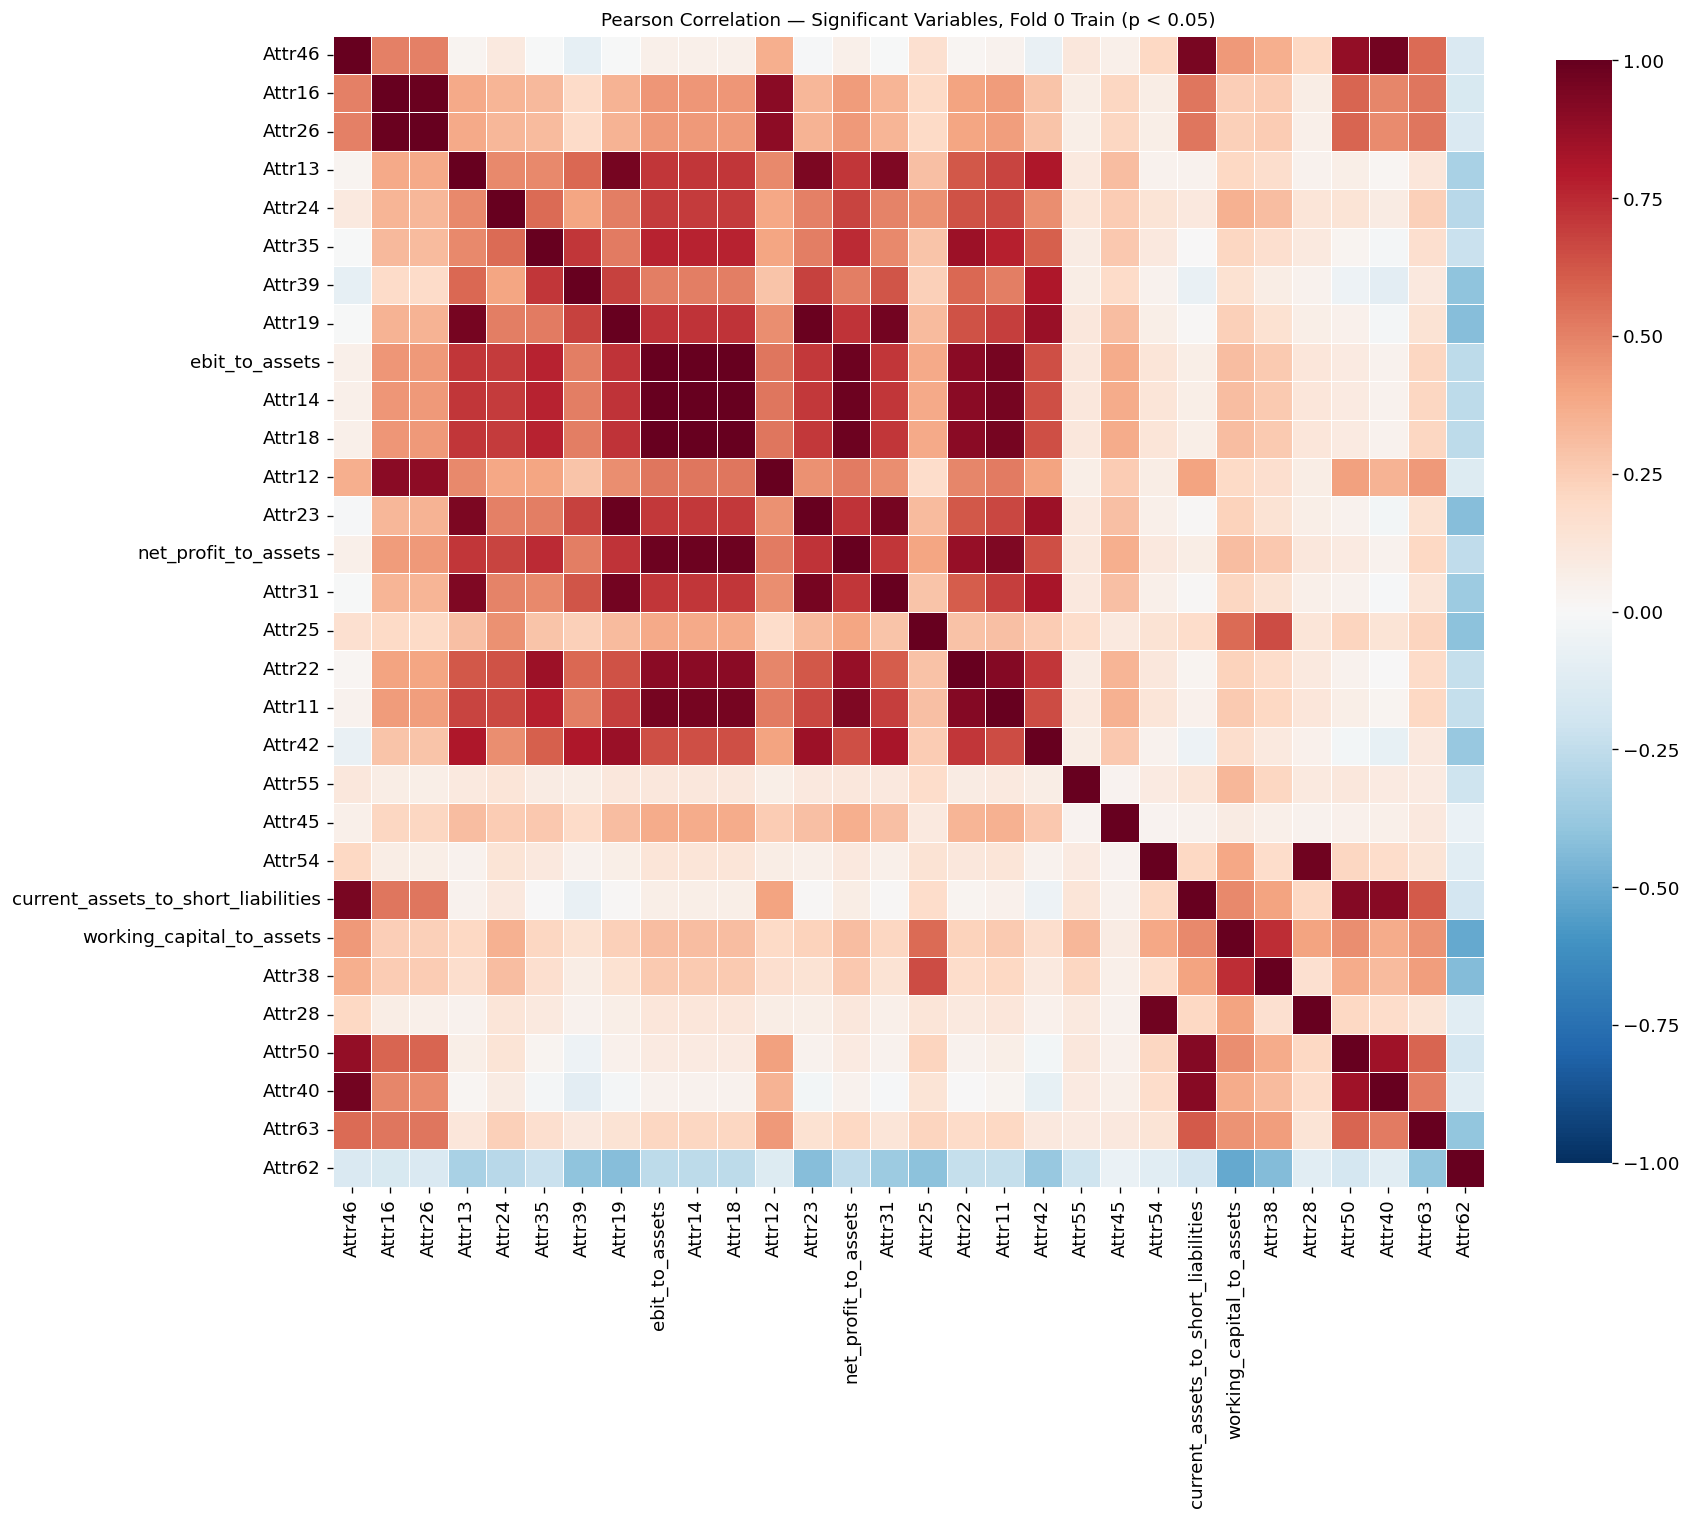

Figure saved: NB02_05_correlation_heatmap_fold0.png

NB02 SUMMARY — FOLD 0 (TRAIN PARTITION)
Total financial variables tested : 64
Significant at p < 0.05          : 57
Significant at p < 0.01          : 55
Significant at p < 0.001         : 52

Top 10 candidate variables for NB03 (univariate logistic regression):
   1. Attr46                                         p=1.00e-56
   2. Attr16                                         p=2.29e-53
   3. Attr26                                         p=8.86e-53
   4. Attr13                                         p=1.79e-49
   5. Attr24                                         p=1.35e-48
   6. Attr35                                         p=1.93e-48
   7. Attr39                                         p=3.90e-47
   8. Attr19                                         p=2.72e-42
   9. ebit_to_assets                                 p=5.65e-41
  10. Attr14                                         p=5.65e-41

Significant variable list saved to:
  ../re

In [1]:
# ============================================================================
# NB02_eda.ipynb  —  Nested CV Version, Step 1: single-fold smoke test
#
# ----------------------------------------------------------------------------
# WHAT CHANGED FROM THE ORIGINAL VERSION
# ----------------------------------------------------------------------------
# The original version read a single, pre-split upgrade_cohort.parquet
# (N = 15,684, the full upgrade-overridden sample) and ran all EDA on it.
#
# In the nested design, factor DISCOVERY (which this EDA feeds into, via
# NB03-NB06) must use ONLY the outer-training partition of a given fold,
# so that the outer-holdout partition of that same fold remains untouched
# until NB07's validation step.
#
# This step-1 version runs the EDA logic on a SINGLE fold (FOLD_ID = 0),
# training partition only, as a smoke test to confirm the logic still
# behaves sensibly on a smaller sample (12,537 firms instead of 15,684)
# before wrapping it in a 5-fold loop. Once you review this fold's output,
# we will convert this into a loop that produces per-fold outputs for all
# five folds.
#
# Input  : data/processed/fold_0/upgrade_cohort_fold0.parquet
#          -> filtered to outer_split == "train" only
# Outputs (note the _fold0 suffix distinguishing this from later 5-fold runs):
#   results/figures/NB02_*_fold0.png
#   results/tables/NB02_01_descriptive_stats_fold0.csv
#   results/tables/NB02_02_mannwhitney_results_fold0.csv
# ============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# ── [NEW] Fold selection for this smoke-test run ─────────────────────────────

FOLD_ID = 0   # will become a loop variable in the next version

fold_cohort_path = os.path.join(PROC_DIR, f"fold_{FOLD_ID}", f"upgrade_cohort_fold{FOLD_ID}.parquet")

# ── Load upgrade cohort — TRAIN PARTITION OF THIS FOLD ONLY ──────────────────
#
# CRITICAL: we filter to outer_split == "train" here. The "holdout" rows in
# this same file exist only for NB07 to use later — this notebook, and every
# notebook feeding factor discovery (NB03-NB06), must never read them.

cohort_full_fold = pd.read_parquet(fold_cohort_path)

assert "outer_split" in cohort_full_fold.columns, (
    "outer_split column missing — check that this file was produced by the "
    "nested-CV version of NB01, not the original single-split version."
)

cohort = cohort_full_fold[cohort_full_fold["outer_split"] == "train"].copy()

n_holdout_excluded = (cohort_full_fold["outer_split"] == "holdout").sum()
print(f"Loaded fold {FOLD_ID} cohort file: {cohort_full_fold.shape}")
print(f"  Excluded {n_holdout_excluded:,} outer-holdout rows (reserved for NB07).")
print(f"  Retained {len(cohort):,} outer-training rows for this EDA run.")

risky = cohort[cohort["group"] == "risky_upgrade"]
safe  = cohort[cohort["group"] == "safe_upgrade"]

print(f"\nFold {FOLD_ID} (train partition): {cohort.shape}")
print(f"  risky_upgrade (comparison) : {len(risky):,}  ({len(risky)/len(cohort)*100:.1f}%)")
print(f"  safe_upgrade  (control)    : {len(safe):,}  ({len(safe)/len(cohort)*100:.1f}%)")
print(f"  Post-upgrade default rate  : {cohort['default'].mean()*100:.2f}%")

# Financial feature columns (exclude non-financial metadata)
#
# NOTE: EXCLUDE set extended with the nested-CV bookkeeping columns
# (outer_fold, outer_split) that did not exist in the original pipeline.
EXCLUDE = {
    "default", "year_horizon", "class", "pd_system",
    "grade_ordinal", "grade_diff", "override_flag", "final_grade_ordinal",
    "system_grade", "group", "is_risky",
    "from_grade", "to_grade", "transition", "high_risk_transition",
    "outer_fold", "outer_split",   # [NEW] nested-CV bookkeeping columns
}
fin_cols = [c for c in cohort.columns if c not in EXCLUDE
            and cohort[c].dtype in [np.float64, np.int64, float, int]]

print(f"\nFinancial features available for analysis: {len(fin_cols)}")


# ── 1. Cohort overview — group size and default rate by grade transition ──────

print(f"\n[Section 1] Cohort overview (fold {FOLD_ID}, train partition)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

group_counts = cohort["group"].value_counts()
axes[0].bar(
    ["safe_upgrade\n(control)", "risky_upgrade\n(comparison)"],
    [group_counts.get("safe_upgrade", 0), group_counts.get("risky_upgrade", 0)],
    color=["#4A90D9", "#E05C3A"],
    width=0.5, edgecolor="white",
)
axes[0].set_title(f"Fold {FOLD_ID} (Train) Cohort: Group Size")
axes[0].set_ylabel("Number of observations")
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=10,
    )

trans_dr = (
    cohort.groupby("transition")["default"]
    .agg(["mean", "count"])
    .query("count >= 20")
    .sort_values("mean", ascending=True)
)
trans_dr["mean_pct"] = trans_dr["mean"] * 100
bar_colors = ["#E05C3A" if v > cohort["default"].mean() * 100
              else "#F4A460" for v in trans_dr["mean_pct"]]
axes[1].barh(trans_dr.index, trans_dr["mean_pct"],
             color=bar_colors, edgecolor="white")
axes[1].axvline(cohort["default"].mean() * 100,
                color="black", linestyle="--", linewidth=1,
                label=f"Fold {FOLD_ID} train avg ({cohort['default'].mean()*100:.1f}%)")
axes[1].set_title(f"Default Rate by Grade Transition (n ≥ 20) — Fold {FOLD_ID} Train")
axes[1].set_xlabel("Default rate (%)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + f"NB02_01_cohort_overview_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB02_01_cohort_overview_fold{FOLD_ID}.png")


# ── 2. Descriptive statistics — risky vs safe ─────────────────────────────────

print(f"\n[Section 2] Descriptive statistics (fold {FOLD_ID}, train partition)")

desc_rows = []
for col in fin_cols:
    r_vals = risky[col].dropna()
    s_vals = safe[col].dropna()
    desc_rows.append({
        "feature"        : col,
        "risky_mean"     : r_vals.mean(),
        "risky_median"   : r_vals.median(),
        "risky_std"      : r_vals.std(),
        "safe_mean"      : s_vals.mean(),
        "safe_median"    : s_vals.median(),
        "safe_std"       : s_vals.std(),
        "mean_diff"      : r_vals.mean() - s_vals.mean(),
        "median_diff"    : r_vals.median() - s_vals.median(),
    })

desc_df = pd.DataFrame(desc_rows).set_index("feature").round(4)
desc_df["abs_mean_diff"] = desc_df["mean_diff"].abs()
desc_df_sorted = desc_df.sort_values("abs_mean_diff", ascending=False)

out_path = TABLE_DIR + f"NB02_01_descriptive_stats_fold{FOLD_ID}.csv"
desc_df_sorted.to_csv(out_path)
print(f"Saved: {out_path}")
print(f"\nTop 10 features by absolute mean difference (risky - safe):")
print(desc_df_sorted[["risky_mean", "safe_mean", "mean_diff"]].head(10).to_string())


# ── 3. Mann-Whitney U test — all financial variables ─────────────────────────

print(f"\n[Section 3] Mann-Whitney U test (fold {FOLD_ID}, train partition)")

mw_rows = []
for col in fin_cols:
    r_vals = risky[col].dropna()
    s_vals = safe[col].dropna()
    if len(r_vals) < 5 or len(s_vals) < 5:
        continue
    stat, pval = stats.mannwhitneyu(r_vals, s_vals, alternative="two-sided")
    mw_rows.append({
        "feature"  : col,
        "U_stat"   : stat,
        "p_value"  : pval,
        "sig_05"   : pval < 0.05,
        "sig_01"   : pval < 0.01,
        "sig_001"  : pval < 0.001,
    })

mw_df = pd.DataFrame(mw_rows).set_index("feature").sort_values("p_value")
mw_df = mw_df.join(desc_df[["risky_median", "safe_median", "median_diff"]])

out_path = TABLE_DIR + f"NB02_02_mannwhitney_results_fold{FOLD_ID}.csv"
mw_df.to_csv(out_path)
print(f"Saved: {out_path}")

sig_vars = mw_df[mw_df["sig_05"]].index.tolist()
print(f"\nSignificant variables (p < 0.05) : {len(sig_vars)} / {len(mw_df)}")
print(f"Significant variables (p < 0.01) : {mw_df['sig_01'].sum()}")
print(f"Significant variables (p < 0.001): {mw_df['sig_001'].sum()}")
print(f"\nTop 15 most significant variables:")
print(mw_df[["p_value", "risky_median", "safe_median", "median_diff"]].head(15).to_string())


# ── 4. Volcano plot — effect size vs significance ────────────────────────────

print(f"\n[Section 4] Volcano plot (fold {FOLD_ID}, train partition)")

mw_df["n_risky"] = len(risky)
mw_df["n_safe"]  = len(safe)
mw_df["effect_r"] = 1 - 2 * mw_df["U_stat"] / (mw_df["n_risky"] * mw_df["n_safe"])
mw_df["neg_log10_p"] = -np.log10(mw_df["p_value"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(11, 7))

mask_ns = ~mw_df["sig_05"]
ax.scatter(mw_df.loc[mask_ns, "effect_r"],
           mw_df.loc[mask_ns, "neg_log10_p"],
           color="#AAAAAA", alpha=0.6, s=40, label="p ≥ 0.05")

mask_s = mw_df["sig_05"]
ax.scatter(mw_df.loc[mask_s, "effect_r"],
           mw_df.loc[mask_s, "neg_log10_p"],
           color="#E05C3A", alpha=0.8, s=60, label="p < 0.05")

top10 = mw_df[mask_s].nlargest(10, "neg_log10_p")
for feat, row in top10.iterrows():
    ax.annotate(feat.replace("_", "\n"),
                xy=(row["effect_r"], row["neg_log10_p"]),
                xytext=(5, 3), textcoords="offset points",
                fontsize=7, color="#333333")

ax.axhline(-np.log10(0.05), color="red", linestyle="--", linewidth=1,
           label="p = 0.05")
ax.axvline(0, color="black", linestyle="-", linewidth=0.5)
ax.set_xlabel("Effect size (rank-biserial r):  ← higher in safe | higher in risky →")
ax.set_ylabel("−log₁₀(p-value)")
ax.set_title(f"Volcano Plot: Fold {FOLD_ID} Train — risky_upgrade vs safe_upgrade")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + f"NB02_02_volcano_plot_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB02_02_volcano_plot_fold{FOLD_ID}.png")


# ── 5. Box plots — top 20 significant variables ───────────────────────────────

print(f"\n[Section 5] Box plots — top 20 significant variables (fold {FOLD_ID})")

top20 = mw_df[mw_df["sig_05"]].head(20).index.tolist()

if len(top20) == 0:
    print("No significant variables found. Skipping box plots.")
else:
    n_cols = 4
    n_rows = int(np.ceil(len(top20) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()

    plot_data = cohort[cohort["group"].isin(["risky_upgrade", "safe_upgrade"])].copy()

    for ax, col in zip(axes, top20):
        sns.boxplot(
            data=plot_data, x="group", y=col, ax=ax,
            order=["safe_upgrade", "risky_upgrade"],
            palette={"safe_upgrade": "#4A90D9", "risky_upgrade": "#E05C3A"},
            width=0.5, fliersize=2,
            boxprops=dict(alpha=0.8),
        )
        p_val  = mw_df.loc[col, "p_value"]
        p_label = (f"p={p_val:.3f}" if p_val >= 0.001
                   else f"p={p_val:.2e}")
        ax.set_title(f"{col}\n{p_label}", fontsize=8)
        ax.set_xlabel("")
        ax.set_xticklabels(["Safe", "Risky"], fontsize=8)
        ax.set_ylabel("")

    for ax in axes[len(top20):]:
        ax.set_visible(False)

    plt.suptitle(f"Top 20 Significant Variables — Fold {FOLD_ID} Train\n"
                 "(Mann-Whitney U, p < 0.05)",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"NB02_03_boxplots_top20_fold{FOLD_ID}.png", bbox_inches="tight")
    plt.show()
    print(f"Figure saved: NB02_03_boxplots_top20_fold{FOLD_ID}.png")


# ── 6. Distribution histograms — top 6 variables ─────────────────────────────

print(f"\n[Section 6] Distribution histograms — top 6 variables (fold {FOLD_ID})")

top6 = mw_df[mw_df["sig_05"]].head(6).index.tolist()

if len(top6) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, top6):
        ax.hist(safe[col].dropna(), bins=60, alpha=0.55,
                color="#4A90D9", label="safe_upgrade", density=True)
        ax.hist(risky[col].dropna(), bins=60, alpha=0.55,
                color="#E05C3A", label="risky_upgrade", density=True)
        p_val   = mw_df.loc[col, "p_value"]
        p_label = f"p={p_val:.3f}" if p_val >= 0.001 else f"p={p_val:.2e}"
        ax.set_title(f"{col}\n{p_label}", fontsize=8)
        ax.legend(fontsize=8)
        ax.set_ylabel("Density")

    plt.suptitle(f"Distribution of Top 6 Significant Variables — Fold {FOLD_ID} Train",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"NB02_04_histograms_top6_fold{FOLD_ID}.png", bbox_inches="tight")
    plt.show()
    print(f"Figure saved: NB02_04_histograms_top6_fold{FOLD_ID}.png")


# ── 7. Correlation heatmap — significant variables only ───────────────────────

print(f"\n[Section 7] Correlation heatmap — significant variables (fold {FOLD_ID})")

if len(sig_vars) >= 2:
    corr_vars = sig_vars[:30]
    corr      = cohort[corr_vars].corr()

    fig, ax = plt.subplots(figsize=(max(10, len(corr_vars) * 0.5),
                                    max(8,  len(corr_vars) * 0.5)))
    sns.heatmap(
        corr, ax=ax,
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        linewidths=0.3, square=True,
        cbar_kws={"shrink": 0.7},
        annot=len(corr_vars) <= 15,
        fmt=".2f", annot_kws={"size": 7},
    )
    ax.set_title(f"Pearson Correlation — Significant Variables, Fold {FOLD_ID} Train (p < 0.05)",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"NB02_05_correlation_heatmap_fold{FOLD_ID}.png", bbox_inches="tight")
    plt.show()
    print(f"Figure saved: NB02_05_correlation_heatmap_fold{FOLD_ID}.png")


# ── 8. Summary and handoff to NB03 ────────────────────────────────────────────

print("\n" + "=" * 60)
print(f"NB02 SUMMARY — FOLD {FOLD_ID} (TRAIN PARTITION)")
print("=" * 60)
print(f"Total financial variables tested : {len(mw_df)}")
print(f"Significant at p < 0.05          : {len(sig_vars)}")
print(f"Significant at p < 0.01          : {int(mw_df['sig_01'].sum())}")
print(f"Significant at p < 0.001         : {int(mw_df['sig_001'].sum())}")
print()
print("Top 10 candidate variables for NB03 (univariate logistic regression):")
for i, feat in enumerate(mw_df[mw_df["sig_05"]].head(10).index, 1):
    row    = mw_df.loc[feat]
    p_str  = f"{row['p_value']:.4f}" if row['p_value'] >= 0.0001 else f"{row['p_value']:.2e}"
    print(f"  {i:2d}. {feat:<45s}  p={p_str}")
print()
print(f"Significant variable list saved to:")
print(f"  {TABLE_DIR}NB02_02_mannwhitney_results_fold{FOLD_ID}.csv")
print()
print(f"[REMINDER] This run used ONLY fold {FOLD_ID}'s outer-training partition")
print(f"({len(cohort):,} firms). The outer-holdout partition of fold {FOLD_ID}")
print(f"({n_holdout_excluded:,} firms) was not touched and remains reserved for NB07.")
print()
print("Next step → confirm this fold-0 output looks reasonable, then we will")
print("wrap this logic in a 5-fold loop for NB03-NB06.")